In [1]:
pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
# Plotting style
sns.set(style='whitegrid', palette='deep', font_scale=1.3)
%matplotlib inline

In [3]:
method_name_map = {
    # Fixed
    "fixed_64_12": "FX64-12",
    "fixed_128_25": "FX128-25",
    "fixed_256_50": "FX256-50",
    "fixed_512_100": "FX512-100",

    # Recursive Token
    "recursive_token_64_16": "RT64-16",
    "recursive_token_100_20": "RT100-20",
    "recursive_token_128_32": "RT128-32",
    "recursive_token_256_64": "RT256-64",
    "recursive_token_512_128": "RT512-128",

    # Kamradt
    "kamradt_50": "KM50",
    "kamradt_100": "KM100",
    "kamradt_200": "KM200",
    "kamradt_400": "KM400",

    # Other
    "cluster_semantic": "CL",
    "llm_semantic": "LLM",
}


In [ ]:
# Standard scientific imports
import pandas as pd

# Parse method info
table_data = []

for full_name, short_name in method_name_map.items():
    if full_name.startswith("fixed_"):
        method = "Fixed-Token-Chunker"
        parts = full_name.split("_")
        chunk = parts[1]
        overlap = parts[2]
    elif full_name.startswith("recursive_token_"):
        method = "Recursive-Token-Chunker"
        parts = full_name.split("_")
        chunk = parts[2]
        overlap = parts[3]
    elif full_name.startswith("kamradt_"):
        method = "Kamradt-Modified-Chunker"
        chunk = full_name.split("_")[1]
        overlap = "–"
    elif full_name == "cluster_semantic":
        method = "Cluster-Semantic-Chunker"
        chunk = overlap = "–"
    elif full_name == "llm_semantic":
        method = "LLM-Semantic-Chunker"
        chunk = overlap = "–"
    else:
        method = chunk = overlap = "?"

    table_data.append([method, chunk, overlap, short_name])

# Create DataFrame
df = pd.DataFrame(table_data, columns=["Method", "Chunk Size", "Overlap Size", "Short Name"])

# Generate only the tabular environment
tabular_code = df.to_latex(index=False, escape=False)

# Wrap it in a full table environment with centering
full_latex_code = f"""
\\begin{{table}}[htbp]
\\centering
\\scriptsize
\\caption{{Overview of chunking strategies evaluated in this study. Each method is categorized by type, associated chunk size, and overlap size (if applicable). Short names are used throughout the paper for clarity and visual compactness in figures and tables.}}
\\label{{tab:method_details}}
{tabular_code}
\\end{{table}}
"""

# Save to file
with open("./../../Tables/size_shortname.tex", "w") as f:
    f.write(full_latex_code)

In [5]:
## **2. Define File Loading Function**
def load_json_files(folder_path):
    """
    Load all JSON files in the specified folder and return a dictionary.
    The key is the filename (without extension), and the value is the parsed JSON data.
    """
    chunking_results = {}
    
    # Iterate over all files in the directory
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):  # Only process JSON files
            file_path = os.path.join(folder_path, filename)
            
            # Open and read the JSON file
            with open(file_path, "r", encoding="utf-8") as file:
                data = json.load(file)
                
                # Use filename (without .json) as key
                chunking_results[filename.replace(".json", "")] = data
    
    return chunking_results

In [6]:
## **3. Load Data**
# Define the path where JSON files are stored
folder_path = "./../../results/chunking_methods_size"  # CHANGE THIS TO YOUR ACTUAL PATH

# Load all chunking results
chunking_results = load_json_files(folder_path)

# Display loaded methods
print("Loaded chunking methods:", list(chunking_results.keys()))

Loaded chunking methods: ['fixed_512_100', 'fixed_256_50', 'recursive_token_64_16', 'kamradt_400', 'kamradt_50', 'cluster_semantic', 'llm_semantic', 'kamradt_200', 'fixed_128_25', 'fixed_64_12', 'recursive_token_128_32', 'recursive_token_256_64', 'recursive_token_512_128', 'recursive_token_100_20', 'kamradt_100']


In [7]:
import pandas as pd
import re

# Step 1: Extract relevant metrics
method_records = []

for method_name, data_dict in chunking_results.items():
    if not data_dict:
        print(f"⚠️ Skipping {method_name} (empty data)")
        continue

    inner_key = next(iter(data_dict), None)
    if not inner_key or inner_key not in data_dict:
        print(f"⚠️ Skipping {method_name} (unexpected structure)")
        continue

    method_data = data_dict[inner_key]

    method_records.append({
        "method": method_name,
        "iou_mean": method_data.get("iou_mean", None),
        "iou_std": method_data.get("iou_std", None),
        "recall_mean": method_data.get("recall_mean", None),
        "recall_std": method_data.get("recall_std", None),
        "precision_omega_mean": method_data.get("precision_omega_mean", None),
        "precision_omega_std": method_data.get("precision_omega_std", None),
        "precision_mean": method_data.get("precision_mean", None),
        "precision_std": method_data.get("precision_std", None),
    })

# Step 2: Convert to DataFrame
df = pd.DataFrame(method_records)
df["short_method"] = df["method"].map(method_name_map).fillna(df["method"])

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.4f}".format
print(f"✅ Number of loaded methods: {len(df)}")

# Step 3: Build formatted summary table
summary_pretty = pd.DataFrame()

# Extract chunk and overlap sizes
def extract_chunk_overlap(method_name):
    match = re.search(r"_(\d+)_?(\d+)?$", method_name)
    if match:
        chunk_size = int(match.group(1))
        overlap_size = int(match.group(2)) if match.group(2) else 0
        return chunk_size, overlap_size
    return None, None

# Extract and capitalize base method
def extract_base_method(method_name):
    match = re.match(r"([a-zA-Z_]+)", method_name)
    base = match.group(1).rstrip("_") if match else method_name
    return base.capitalize()

summary_pretty["Chunk Size"], summary_pretty["Overlap Size"] = zip(*df["method"].map(extract_chunk_overlap))
summary_pretty["Method"] = df["short_method"]


# Format metrics
columns_to_format = [
    ("iou_mean", "iou_std", "IoU"),
    ("recall_mean", "recall_std", "Recall"),
    ("precision_omega_mean", "precision_omega_std", "Precision@$\Omega$"),
    ("precision_mean", "precision_std", "Precision"),
]

for mean_col, std_col, label in columns_to_format:
    summary_pretty[label] = df.apply(
        lambda row: f"{row[mean_col]:.3f} $\\,\\pm\\,$ {row[std_col]:.3f}", axis=1
    )

# Sort by base method and chunk/overlap sizes
summary_pretty = summary_pretty.sort_values(by=["Method", "Chunk Size", "Overlap Size"])

# Final column order
summary_pretty = summary_pretty[
    ["Method", "Chunk Size", "Overlap Size", "IoU", "Recall", "Precision@$\Omega$", "Precision"]
]

# Step 4: Export to LaTeX
latex_table = summary_pretty.to_latex(index=False, escape=False)
# Wrap in a table environment with \small
wrapped_table = f"""
\\begin{{table}}[htbp]
\\centering
\\scriptsize
\\caption{{Comparison of chunking methods across various configurations, including chunk size and overlap, in a retrieval-augmented generation (RAG) system for chemistry. Metrics include mean and standard deviation for Intersection over Union (IoU), Recall, and Precision at threshold $\Omega$.}}
\\label{{tab:summary_table_size}}
{latex_table}
\\end{{table}}
"""
with open("./../../Tables/summary_table_size.tex", "w") as f:
    f.write(wrapped_table)

# Step 5: Display table
# display(summary_pretty)


✅ Number of loaded methods: 15


/tmp/ipykernel_458206/3575468813.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_458206/3575468813.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_458206/3575468813.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_458206/3575468813.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


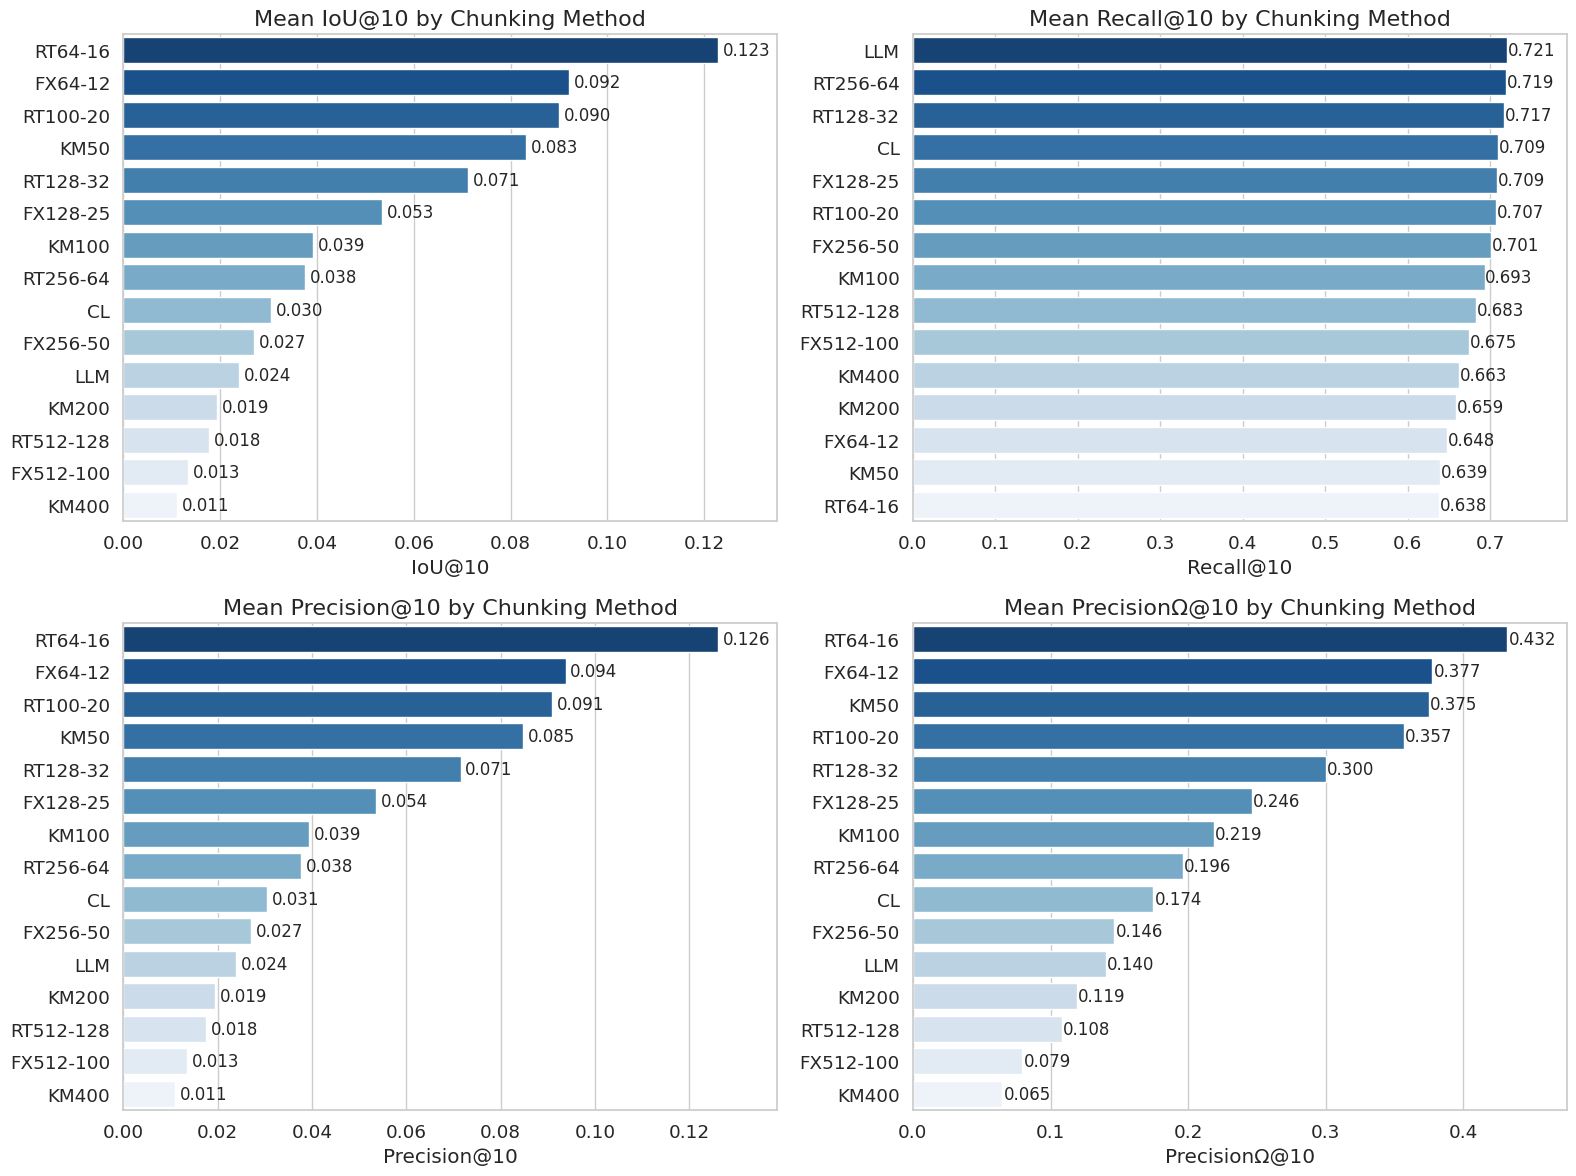

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style='whitegrid', palette='viridis', font_scale=1.2)

# Metrics and display names
metrics = {
    "iou_mean": "IoU@10",
    "recall_mean": "Recall@10",
    "precision_mean": "Precision@10",
    "precision_omega_mean": "PrecisionΩ@10"
}

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten 2D array to 1D for easy looping

# Plot each metric
for ax, (col, label) in zip(axes, metrics.items()):
    sorted_df = df.set_index('short_method')[col].sort_values(ascending=False)

    sns.barplot(
        x=sorted_df.values,
        y=sorted_df.index,
        ax=ax,
        palette="Blues_r"
    )
    
    # Annotate each bar with the value
    for i, val in enumerate(sorted_df.values):
        ax.text(val + 0.001, i, f"{val:.3f}", va='center', fontsize=12)
    
    ax.set_title(f"Mean {label} by Chunking Method", fontsize=16)
    ax.set_xlabel(label)
    ax.set_ylabel("")

    ax.set_xlim(0, sorted_df.max() * 1.1)

# Adjust layout
plt.tight_layout()
plt.savefig("./../../figures/size_all_metrics_barplots_2x2.jpg", dpi=300)
plt.show()


In [9]:
import pandas as pd
import numpy as np

records = []

for method_name, method_data in chunking_results.items():
    corpora_scores = method_data.get(method_name, {}).get("corpora_scores", {})

    
    if not corpora_scores:
        print(f"⚠️ Skipping '{method_name}' — no corpora_scores found.")
        continue

    for corpus_id, scores in corpora_scores.items():
        if not scores:
            continue

        record = {
            "method": method_name,
            "corpus": corpus_id,
            "iou": np.mean(scores.get("iou_scores", [])),
            "recall": np.mean(scores.get("recall_scores", [])),
            "precision": np.mean(scores.get("precision_scores", [])),
            "precision_omega": np.mean(scores.get("precision_omega_scores", [])),
        }
        records.append(record)

df_corpus = pd.DataFrame(records)
df_corpus["short_method"] = df_corpus["method"].map(method_name_map).fillna(df_corpus["method"])
# print(df_corpus.shape)
# print(df_corpus.head())


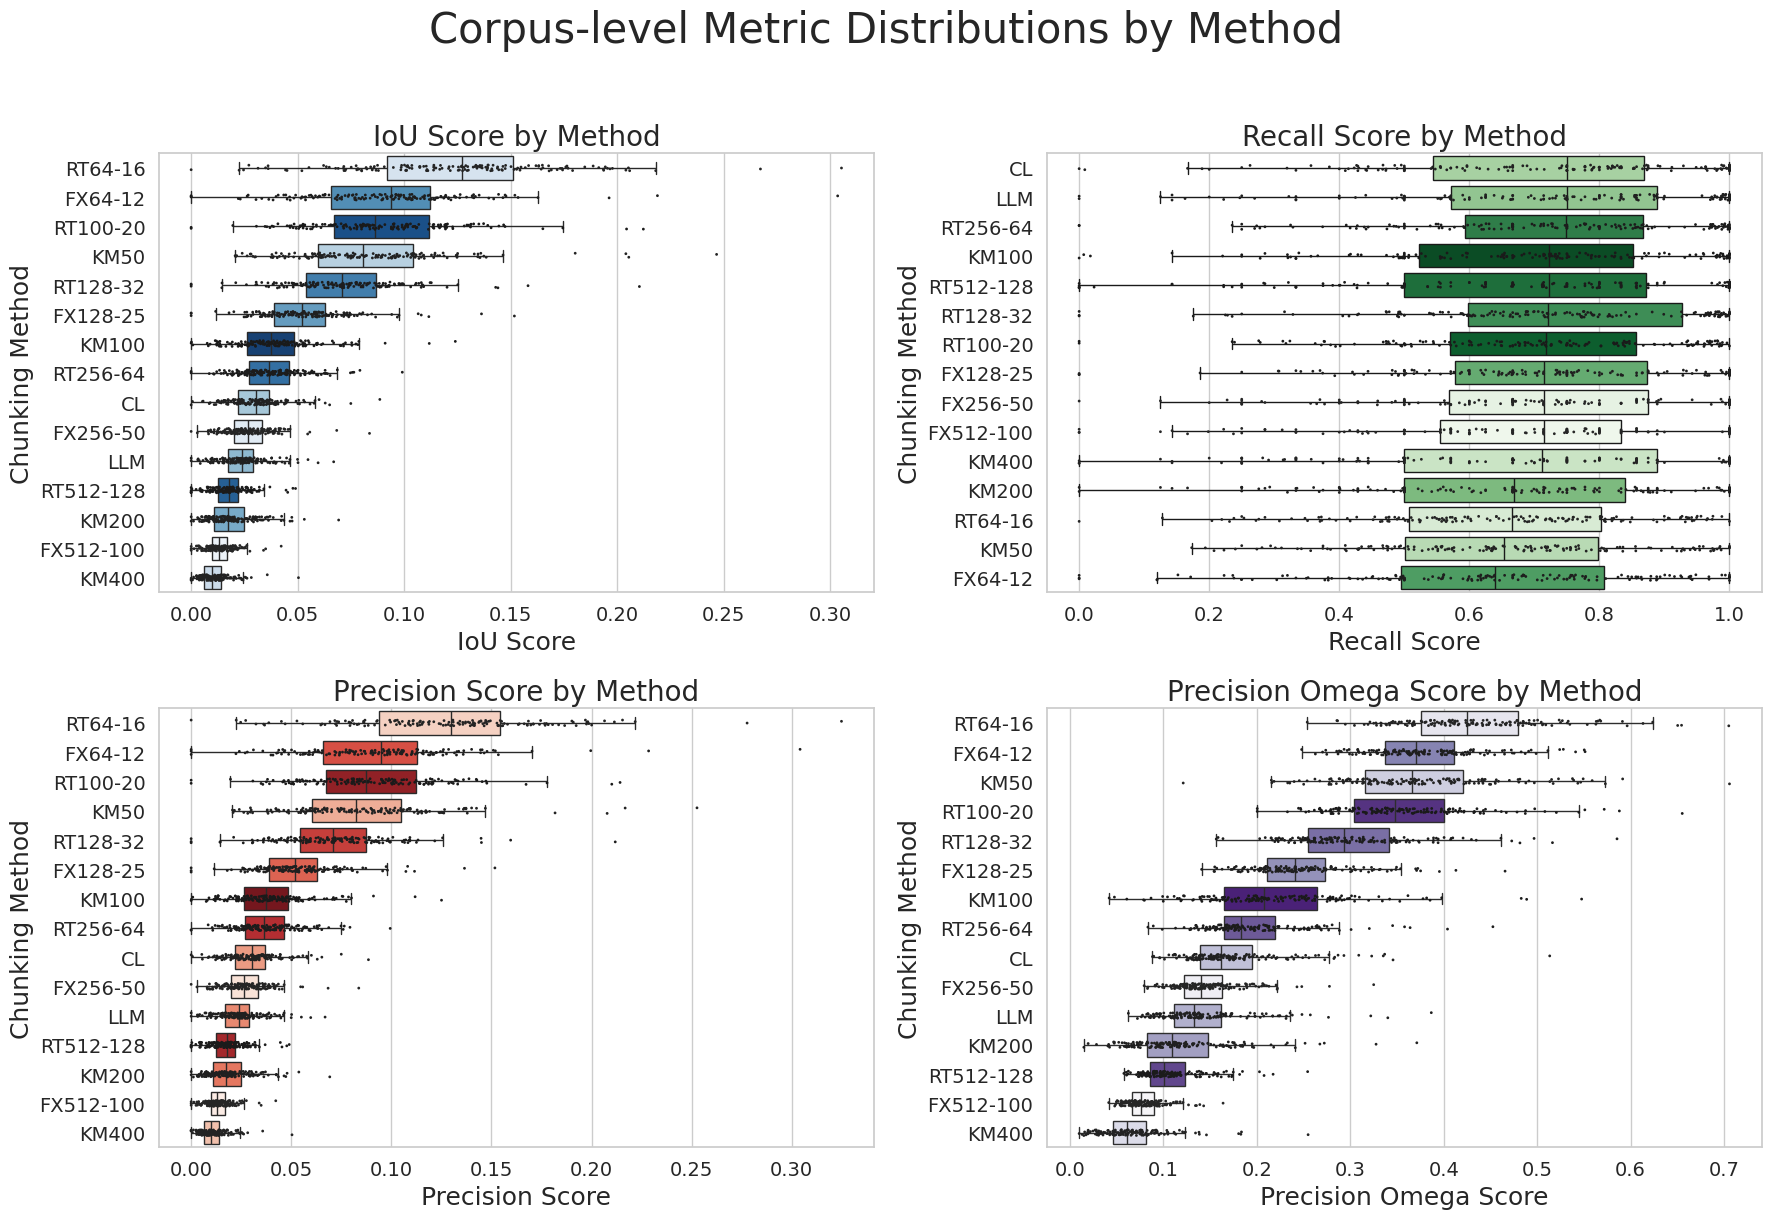

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global Seaborn style
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 26
})

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Corpus-level Metric Distributions by Method", fontsize=30, y=1.02)

# Define metric settings
metrics = [
    ("iou", "IoU Score", "Blues"),
    ("recall", "Recall Score", "Greens"),
    ("precision", "Precision Score", "Reds"),
    ("precision_omega", "Precision Omega Score", "Purples"),
]

# Flatten axes for easy indexing
axes = axes.flatten()

# Plot each metric
for ax, (metric, ylabel, palette) in zip(axes, metrics):
    # Sort by median value using short method names
    sorted_methods = df_corpus.groupby("short_method")[metric].median().sort_values(ascending=False).index.tolist()

    sns.boxplot(
        data=df_corpus, y="short_method", x=metric, hue="short_method",
        palette=palette, showfliers=False, legend=False, ax=ax, order=sorted_methods
    )

    sns.stripplot(
        data=df_corpus, y="short_method", x=metric, hue="short_method",
        palette="dark:k", legend=False, size=2, jitter=True, ax=ax, order=sorted_methods
    )

    ax.set_title(f"{ylabel} by Method")
    ax.set_ylabel("Chunking Method")
    ax.set_xlabel(ylabel)
    ax.tick_params(axis="y", labelrotation=0)

# Final layout
plt.tight_layout()
plt.savefig("./../../figures/size_curpose_level_metric.jpg", dpi=300, bbox_inches='tight')

plt.show()


/tmp/ipykernel_458206/1709112949.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20b_r")


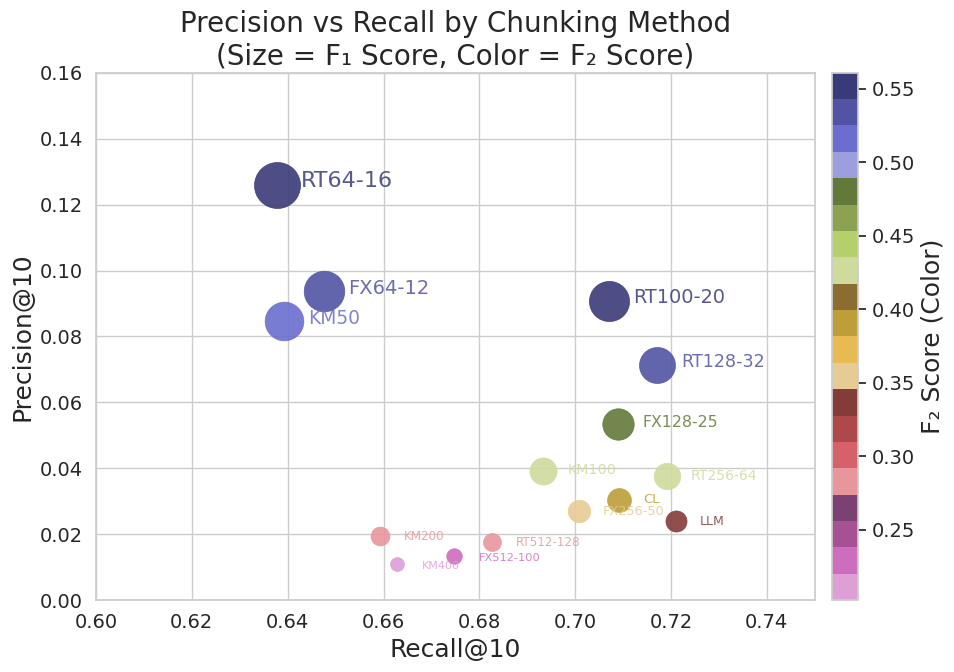


=== Performance Table by Method (sorted by F2 score) ===
   Method  precision_mean  recall_mean     F1     F2
 RT100-20          0.0908       0.7071 0.1610 0.5607
  RT64-16          0.1260       0.6378 0.2105 0.5517
 RT128-32          0.0715       0.7171 0.1300 0.5322
  FX64-12          0.0938       0.6476 0.1638 0.5277
     KM50          0.0847       0.6393 0.1496 0.5106
 FX128-25          0.0536       0.7089 0.0996 0.4821
 RT256-64          0.0376       0.7191 0.0715 0.4237
    KM100          0.0393       0.6933 0.0744 0.4228
       CL          0.0305       0.7092 0.0585 0.3822
 FX256-50          0.0271       0.7007 0.0521 0.3581
      LLM          0.0239       0.7211 0.0463 0.3398
    KM200          0.0194       0.6592 0.0376 0.2904
RT512-128          0.0176       0.6827 0.0343 0.2783
FX512-100          0.0134       0.6748 0.0263 0.2330
    KM400          0.0110       0.6629 0.0216 0.2020


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# F-beta score calculation
def fbeta_score(precision, recall, beta):
    beta_sq = beta ** 2
    return (1 + beta_sq) * (precision * recall) / ((beta_sq * precision) + recall + 1e-8)

# Prepare data
pr_df = df[['method', 'recall_mean', 'precision_mean']].copy()
pr_df["short_method"] = pr_df["method"].map(method_name_map).fillna(pr_df["method"])

# Compute F1 and F2 scores
pr_df['F1'] = fbeta_score(pr_df['precision_mean'], pr_df['recall_mean'], beta=1)
pr_df['F2'] = fbeta_score(pr_df['precision_mean'], pr_df['recall_mean'], beta=5)

# Normalize F1 for size (100–1100 range)
f1_min, f1_max = pr_df['F1'].min(), pr_df['F1'].max()
pr_df['size'] = 100 + 1000 * (pr_df['F1'] - f1_min) / (f1_max - f1_min)

# Normalize F2 for color
f2_min, f2_max = pr_df['F2'].min(), pr_df['F2'].max()
norm = mcolors.Normalize(vmin=f2_min, vmax=f2_max)
cmap = cm.get_cmap("tab20b_r")
pr_df['color'] = pr_df['F2'].apply(lambda x: cmap(norm(x)))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in pr_df.iterrows():
    ax.scatter(row['recall_mean'], row['precision_mean'],
               s=row['size'], color=row['color'], alpha=0.9, edgecolor=row['color'], linewidth=0.5)
    scaled_font = 8 + 8 * (row['F1'] - f1_min) / (f1_max - f1_min)
    # Annotate with method name
    ax.text(row['recall_mean'] + 0.005, row['precision_mean'] - 0.002,
            row['short_method'], fontsize=scaled_font, ha='left', va='bottom', alpha=0.85, color=row['color'])

# Axis styling
ax.set_title("Precision vs Recall by Chunking Method\n(Size = F₁ Score, Color = F₂ Score)")
ax.set_xlabel("Recall@10")
ax.set_ylabel("Precision@10")
ax.set_xlim(0.6, 0.75)
ax.set_ylim(0.0, 0.16)
ax.grid(True)

# Colorbar for F2
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("F₂ Score (Color)")

# Save and show
plt.tight_layout()
plt.savefig("./../../figures/size_plot_scatter_f1_size_f2_color.jpg", dpi=300, bbox_inches='tight')
plt.show()


# Prepare and print the summary table
summary_df = pr_df[['short_method', 'precision_mean', 'recall_mean', 'F1', 'F2']].copy()
summary_df = summary_df.rename(columns={"short_method": "Method"})

summary_df = summary_df.round(4).sort_values(by='F2', ascending=False)

print("\n=== Performance Table by Method (sorted by F2 score) ===")
print(summary_df.to_string(index=False))

summary_df = summary_df.rename(columns={
    "precision_mean": "Precision\\_mean",
    "recall_mean": "Recall\\_mean",
    "F1": "$F_1$",
    "F2": "$F_2$"
})

summary_df = summary_df.rename(columns={
    "precision_mean": "Precision\\_mean",
    "recall_mean": "Recall\\_mean",
    "F1": "$F_1$",
    "F2": "$F_2$"
})

# Export LaTeX tabular only
latex_table = summary_df.to_latex(index=False, escape=False)

# Wrap with full table environment
wrapped_table = f"""
\\begin{{table}}[htbp]
\\centering
\\scriptsize
\\caption{{Precision and recall metrics (mean values) for each chunking method evaluated, sorted by $F_2$ score to emphasize performance with stronger recall weighting. Bubble sizes and colors in the related figure correspond to $F_1$ and $F_2$ scores respectively.}}
\\label{{tab:size_precision_recall_summary}}
{latex_table}
\\end{{table}}
"""

with open("./../../Tables/size_precision_recall_summary.tex", "w") as f:
    f.write(wrapped_table)


In [12]:
# Add a 'family' column based on naming convention in 'method'
def classify_family(method):
    if 'recursive' in method:
        return 'recursive'
    else:
        return 'fixed'

df['family'] = df['method'].apply(classify_family)


/tmp/ipykernel_458206/3344118421.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_iou, x='Family', y='iou_mean', palette='Blues_r')


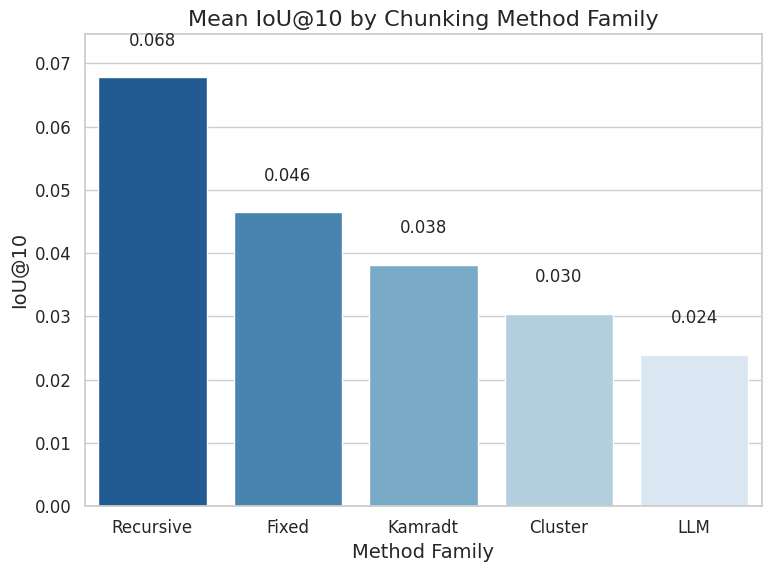

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Prettify display names
family_display_map = {
    "recursive": "Recursive",
    "fixed": "Fixed",
    "kamradt": "Kamradt",
    "cluster_semantic": "Cluster",
    "llm_semantic": "LLM",
    "other": "Other"
}



# Define more detailed method categorization
def classify_family(method):
    if "recursive" in method:
        return "recursive"
    elif "fixed" in method:
        return "fixed"
    elif "kamradt" in method:
        return "kamradt"
    elif "cluster" in method:
        return "cluster_semantic"
    elif "llm" in method:
        return "llm_semantic"
    else:
        return "other"

# Assign family to each method
df['family'] = df['method'].apply(classify_family)

# Calculate mean IoU per family
family_iou = df.groupby('family')['iou_mean'].mean().reset_index()
family_iou["Family"] = family_iou["family"].map(family_display_map)
# Calculate mean IoU per family
family_iou = df.groupby('family')['iou_mean'].mean().reset_index()
family_iou["Family"] = family_iou["family"].map(family_display_map)

# Sort by IoU descending
family_iou = family_iou.sort_values(by='iou_mean', ascending=False).reset_index(drop=True)

# Plotting
plt.figure(figsize=(8, 6))
sns.barplot(data=family_iou, x='Family', y='iou_mean', palette='Blues_r')

# Add value labels with font size
for idx, row in family_iou.iterrows():
    plt.text(idx, row['iou_mean'] + 0.005, f"{row['iou_mean']:.3f}", ha='center', fontsize=12)

# Set title and labels with font size
plt.title("Mean IoU@10 by Chunking Method Family", fontsize=16)
plt.xlabel("Method Family", fontsize=14)
plt.ylabel("IoU@10", fontsize=14)

# Set tick label font size
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, family_iou['iou_mean'].max() * 1.1)
plt.tight_layout()
plt.savefig("./../../figures/size_plot_iou_by_family.jpg", dpi=300)

plt.show()



In [14]:
summary_pretty.to_csv("summary_table.csv", index=False)
pr_df.to_csv("precision_recall_points.csv", index=False)
iou_means = df_corpus.groupby("method")["iou"].mean().sort_values(ascending=False)

iou_means.to_csv("iou_sorted.csv", header=["iou"])
